# Corporate Bullshit Detector (featuring Jev)

The **Corporate Bullshit Detector** is a small experimental AI/ML project for analyzing **English-language corporate and professional social-media communication, especially LinkedIn posts**.

Its primary goal is to estimate how strongly a piece of corporate or professional communication exhibits characteristics commonly associated with corporate bullshit. Typical inputs include company posts, founder or executive posts, startup announcements, product launches, consulting thought leadership, AI hype, and other professional social-media content.

The detector does not claim to determine with absolute certainty whether a post is "bullshit" or "real". Instead, it evaluates several observable linguistic characteristics and expresses them as probabilities.

The system produces **probabilistic scores across separate dimensions** rather than asking a single model whether a text is "bullshit". A final overall Corporate Bullshit Score can later be derived deterministically from these individual signals.

Press releases and other corporate communication may still be used as secondary comparison examples, but professional social-media communication is the project's primary target domain.

## Core Decision Questions

| # | Dimension | Question | Output |
|---|---|---|---|
| 1 | Buzzword Saturation | How likely is it that this text relies heavily on trendy business, technology, startup, or marketing buzzwords rather than using them only where necessary? | `P(buzzword_saturation)` |
| 2 | Vagueness & Corporate Clichés | How likely is it that this text uses vague, generic, or formulaic corporate language while providing little clarity about what is actually being done, offered, changed, or achieved? | `P(vagueness)` |
| 3 | Grandiosity & Implausible Claims | How likely is it that this text makes exaggerated, grandiose, or implausible claims about its importance, novelty, capabilities, impact, or future consequences? | `P(grandiosity)` |
| 4 | Concrete Information | How likely is it that this text contains specific, concrete information about what happened, what was built, how something works, or what measurable result was achieved? | `P(concrete_information)` |


In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
from abc import ABC, abstractmethod
from dataclasses import dataclass

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from typesafe_sdk import Noul, TypeSafeClient

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, f1_score, precision_score, recall_score

load_dotenv("../../../corporate_bullshit.env")

True

## Datasets

The project uses two related datasets.

### Raw Dataset

`corporate_bullshit_raw_dataset.csv`

The raw dataset contains a broader collection of synthetic and authentic corporate or professional communication, with a strong focus on LinkedIn-style posts. It serves as the general pool of examples used for experimentation and later model evaluation.

| Column | Description |
|---|---|
| `id` | Unique sample identifier |
| `synthetic_or_real` | Indicates whether the sample is synthetic or based on authentic public communication |
| `text` | The corporate or professional communication to be analyzed |
| `source_type` | Type of communication, such as LinkedIn post, press release, or corporate update |
| `domain` | Industry or subject domain |
| `archetype` | Descriptive construction category used when assembling the dataset; not a ground-truth label |

### Golden Set

`corporate_bullshit_golden_set.csv`

The golden set is a manually reviewed subset of the raw dataset. Each sample was labeled according to the four dimensions used by the detector and acts as the human reference for evaluation.

| Column | Description |
|---|---|
| `id` | Unique sample identifier matching the raw dataset |
| `text` | Text being evaluated |
| `buzzword_saturation` | Human label for excessive or disproportionate use of technical or corporate buzzwords |
| `vagueness` | Human label for vague, generic, or formulaic corporate language |
| `grandiosity` | Human label for exaggerated, inflated, or implausible claims |
| `concrete_information` | Human label for specific, factual, measurable, or otherwise concrete information |
| `notes` | Optional notes recorded during manual labeling |

The human labels use `0` for a negative classification, `1` for a positive classification, and `?` for genuinely ambiguous or borderline cases.

In [208]:
df_raw = pd.read_csv("../data/raw/corporate_bullshit_raw_dataset.csv")
golden_df = pd.read_csv("../data/raw/corporate_bullshit_golden_set.csv")

print("Raw shape:", df_raw.shape)
print("Golden set shape:", golden_df.shape)


Raw shape: (180, 6)
Golden set shape: (63, 6)


In [209]:
display(df_raw.head(2))
display(golden_df.head(2))

,id,synthetic_or_real,text,source_type,domain,archetype
0,CBS001,synthetic,We shipped version 2.3 of our retrieval servic...,linkedin_post,ai_tech,buzzwords_but_concrete
1,CBS002,synthetic,Good teams make room for different perspective...,linkedin_post,software,vague_but_not_grandiose


,id,text,buzzword_saturation,vagueness,grandiosity,concrete_information
0,CBS001,We shipped version 2.3 of our retrieval servic...,0,0,0,1
1,CBS002,Good teams make room for different perspective...,0,1,0,0


## Decision Provider Interface

First we need to define the resulting datamodel that the bullshit classifier returns.

In [210]:
@dataclass
class DecisionResult:
    buzzword_saturation: float
    vagueness: float
    grandiosity: float
    concrete_information: float

    def __post_init__(self):
        if any(not 0.0 <= probability <= 1.0 for probability in (
            self.buzzword_saturation,
            self.vagueness,
            self.grandiosity,
            self.concrete_information,
        )):
            raise ValueError("Probabilities must be between 0.0 and 1.0.")

    def to_dict(self):
        return {
            "buzzword_saturation": self.buzzword_saturation,
            "vagueness": self.vagueness,
            "grandiosity": self.grandiosity,
            "concrete_information": self.concrete_information,
        }

result = DecisionResult(0.7, 0.4, 0.2, 0.8)
display(result.to_dict())

{'buzzword_saturation': 0.7,
 'vagueness': 0.4,
 'grandiosity': 0.2,
 'concrete_information': 0.8}

The provider interface and the initial LLM dummy implementation follow.

In [238]:
DECISION_QUESTIONS = {
    "buzzword_saturation": "How likely is it that this text contains a noticeable concentration of trendy business, technology, startup, consulting, or marketing buzzwords, especially when several are stacked or used ornamentally?",
    "vagueness": "How likely is it that vague or generic language materially dominates the text, even if some concrete details are also present? Do not treat brevity or missing external context alone as vagueness.",
    "grandiosity": "How likely is it that the overall text makes clearly exaggerated or grandiose claims whose stated importance, novelty, capabilities, impact, or future consequences are substantially disproportionate to what the text itself describes or supports? Individual promotional words, superlatives, or large numbers alone should not be sufficient.",
    "concrete_information": "How likely is it that this text contains specific, concrete information about what happened, what was built, how something works, or what measurable result was achieved?",
}

DECISION_SYSTEM_INSTRUCTIONS = (
    "Act as a probabilistic evaluator of English-language corporate and professional social-media "
    "communication, especially LinkedIn posts. Evaluate each dimension independently and return "
    "probabilities from 0.0 to 1.0, where a high probability means the answer to that question is yes. "
    "Marketing language alone is not automatically bullshit, and AI-generated style alone is not "
    "automatically bullshit. Technical terminology used appropriately should not automatically count "
    "as buzzword saturation. Concrete information may coexist with buzzwords, marketing language, or "
    "grandiosity. Judge only the supplied text; do not perform external fact checking. Return only the "
    "four probabilities, without explanations, reasoning, labels, verdicts, or a final bullshit score."
)


In [212]:

class DecisionProvider(ABC):
    @abstractmethod
    def analyze(self, text: str) -> DecisionResult:
        ...

class DecisionProbabilities(BaseModel):
    buzzword_saturation: float = Field(ge=0.0, le=1.0)
    vagueness: float = Field(ge=0.0, le=1.0)
    grandiosity: float = Field(ge=0.0, le=1.0)
    concrete_information: float = Field(ge=0.0, le=1.0)


### Legacy Dummy Provider through OpenRouter

Retained for reference; the analysis below uses `jev_provider` exclusively.

In [213]:

class DummyLLMProvider(DecisionProvider):
    def __init__(self):
        load_dotenv()
        self.model = "deepseek/deepseek-chat-v3.1"
        self.client = OpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=os.getenv("OPENROUTER_API_KEY"))

    def analyze(self, text: str) -> DecisionResult:
        questions = "\n".join(
            f"{name}: {question}" for name, question in DECISION_QUESTIONS.items()
        )
        response = self.client.responses.parse(
            model=self.model,
            input=[
                {"role": "system", "content": DECISION_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": f"Decision questions:\n{questions}\n\nText to evaluate:\n{text}"},
            ],
            text_format=DecisionProbabilities,
            temperature=0,
        )
        parsed = response.output_parsed
        if parsed is None:
            raise ValueError("The model response did not contain parsed probabilities.")
        return DecisionResult(**parsed.model_dump())



### Jev Provider

In [214]:
class JevProvider(DecisionProvider):
    def __init__(self, mode: str = "openrouter"):
        if mode not in {"openrouter", "native"}:
            raise ValueError("mode must be either 'openrouter' or 'native'")

        if mode == "openrouter":
            self.client = TypeSafeClient(
                api_key=os.environ["OPENROUTER_API_KEY"],
                base_url="https://openrouter.ai/api",
                model="~typesafe/jev-latest",
            )
        else:
            self.client = TypeSafeClient(
                api_key=os.environ["TYPESAFE_API_KEY"],
            )

        self.questions = {
            name: Noul(instructions=question)
            for name, question in DECISION_QUESTIONS.items()
        }

    def analyze(self, text: str) -> DecisionResult:
        response = self.client.system_one(text, self.questions)
        return DecisionResult(
            buzzword_saturation=response.nouls["buzzword_saturation"].noul,
            vagueness=response.nouls["vagueness"].noul,
            grandiosity=response.nouls["grandiosity"].noul,
            concrete_information=response.nouls["concrete_information"].noul,
        )

Testing Jev through OpenRouter:

In [215]:
jev_provider = JevProvider()
result = jev_provider.analyze(
    "We're thrilled to unveil our next-generation agentic AI ecosystem, empowering organizations "
    "to unlock transformative productivity and redefine the future of work."
)
display(result)
display(result.to_dict())

DecisionResult(buzzword_saturation=0.97, vagueness=0.91, grandiosity=0.88, concrete_information=0.07)

{'buzzword_saturation': 0.97,
 'vagueness': 0.91,
 'grandiosity': 0.88,
 'concrete_information': 0.07}

Constructing the native TypeSafe configuration without making a request:

In [216]:
# native_jev_provider = JevProvider(mode="native")

### Collecting Results from Golden Set

Run each golden-set text through the provider and store predictions in a separate DataFrame.

In [217]:
predictions = []

for _, row in golden_df.iterrows():
    result = jev_provider.analyze(row["text"])
    predictions.append({
        "id": row["id"],
        "buzzword_saturation_pred": result.buzzword_saturation,
        "vagueness_pred": result.vagueness,
        "grandiosity_pred": result.grandiosity,
        "concrete_information_pred": result.concrete_information,
    })

predictions_df = pd.DataFrame(
    predictions,
    columns=[
        "id",
        "buzzword_saturation_pred",
        "vagueness_pred",
        "grandiosity_pred",
        "concrete_information_pred",
    ],
)

display(predictions_df.head())
print("predictions_df shape:", predictions_df.shape)

,id,buzzword_saturation_pred,vagueness_pred,grandiosity_pred,concrete_information_pred
0,CBS001,0.46,0.16,0.10,0.98
1,CBS002,0.32,0.68,0.06,0.21
2,CBS004,0.69,0.39,0.17,0.47
3,CBS005,0.28,0.37,0.57,0.90
4,CBS006,0.06,0.12,0.04,0.94


predictions_df shape: (63, 5)


In [218]:
pred_output_path = Path("../data/processed/corporate_bullshit_jev_predictions.csv")

In [219]:
pred_output_path.parent.mkdir(parents=True, exist_ok=True)
predictions_df.to_csv(pred_output_path, index=False)
print(f"Saved {len(predictions_df)} rows to {pred_output_path.resolve()}")

Saved 63 rows to /home/flo/IdeaProjects/corporate-bullshit-detector/corporate-bullshit-detector/data/processed/corporate_bullshit_jev_predictions.csv


### Merge Predictions with Golden Set Human Labels

In [220]:
predictions_df = pd.read_csv(pred_output_path)

human_columns = [
    "id", "text", "buzzword_saturation", "vagueness",
    "grandiosity", "concrete_information"
]
prediction_columns = [
    "buzzword_saturation_pred", "vagueness_pred",
    "grandiosity_pred", "concrete_information_pred",
]

evaluation_df = golden_df.reindex(columns=human_columns).merge(
    predictions_df[["id", *prediction_columns]], on="id", how="inner"
)
assert len(evaluation_df) == len(golden_df), "Merged row count differs from the golden set"

print(f"Merged rows: {len(evaluation_df)} (expected {len(golden_df)})")
display(evaluation_df.head())
print("Missing prediction values:", evaluation_df[prediction_columns].isna().sum().to_dict())

Merged rows: 63 (expected 63)


,id,text,buzzword_saturation,vagueness,grandiosity,concrete_information,buzzword_saturation_pred,vagueness_pred,grandiosity_pred,concrete_information_pred
0,CBS001,We shipped version 2.3 of our retrieval servic...,0,0,0,1,0.46,0.16,0.10,0.98
1,CBS002,Good teams make room for different perspective...,0,1,0,0,0.32,0.68,0.06,0.21
2,CBS004,Transformation rarely fails because the strate...,?,1,0,0,0.69,0.39,0.17,0.47
3,CBS005,If we can make heat pumps easy to install in o...,0,1,1,?,0.28,0.37,0.57,0.90
4,CBS006,Our outpatient clinic in Leeds will extend its...,0,0,0,1,0.06,0.12,0.04,0.94


Missing prediction values: {'buzzword_saturation_pred': 0, 'vagueness_pred': 0, 'grandiosity_pred': 0, 'concrete_information_pred': 0}


## Evaluation

The Jev decision provider is evaluated against the manually labeled golden set.

Because the detector produces probabilities rather than only binary classifications, the evaluation considers both **probability quality** and **classification performance**.

The following methods are used:

- **Brier Score** measures how close predicted probabilities are to the human reference labels.
- **ROC-AUC** measures how well the model separates positive from negative examples independently of a fixed classification threshold.
- **F1 Score** is evaluated across different thresholds to explore which cutoff provides a useful balance between precision and recall.
- **Score Distributions** show how predicted probabilities differ between human-labeled positive and negative examples.
- **False Positive / False Negative Analysis** examines the strongest disagreements between the model and the human labels.

Ambiguous human labels (`?`) are excluded from quantitative metrics for the respective dimension but remain available for later qualitative inspection.

In [221]:
dimension_columns = {
    "buzzword_saturation": "buzzword_saturation_pred",
    "vagueness": "vagueness_pred",
    "grandiosity": "grandiosity_pred",
    "concrete_information": "concrete_information_pred",
}

prepared_by_dimension = {}
for label_col, pred_col in dimension_columns.items():
    usable = evaluation_df.loc[
        evaluation_df[label_col] != "?", ["id", label_col, pred_col]
    ].copy()
    usable = usable.rename(columns={label_col: "label", pred_col: "prediction"})
    usable["label"] = usable["label"].astype(int)
    prepared_by_dimension[label_col] = usable
    print(f"{label_col}: {len(usable)} usable samples")

buzzword_saturation: 59 usable samples
vagueness: 58 usable samples
grandiosity: 60 usable samples
concrete_information: 62 usable samples


### Brier Score

In [222]:
brier_rows = []
for dimension, samples in prepared_by_dimension.items():
    brier_rows.append({
        "dimension": dimension,
        "brier_score": brier_score_loss(samples["label"], samples["prediction"]),
    })

brier_results = pd.DataFrame(brier_rows).sort_values("brier_score").reset_index(drop=True)
print("Brier Score: 0.0 represents perfect probabilistic predictions; lower values are better.")
display(brier_results)

Brier Score: 0.0 represents perfect probabilistic predictions; lower values are better.


,dimension,brier_score
0,concrete_information,0.097871
1,vagueness,0.123600
2,grandiosity,0.133657
3,buzzword_saturation,0.184417


### ROC-AUC

In [223]:

auc_rows = []
for dimension, samples in prepared_by_dimension.items():
    auc_rows.append({
        "dimension": dimension,
        "roc_auc": roc_auc_score(samples["label"], samples["prediction"]),
    })

auc_results = pd.DataFrame(auc_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
print("ROC-AUC: 0.5 is approximately random ranking; 1.0 is perfect separation; higher values are better.")
display(auc_results)

ROC-AUC: 0.5 is approximately random ranking; 1.0 is perfect separation; higher values are better.


,dimension,roc_auc
0,concrete_information,0.938542
1,buzzword_saturation,0.932773
2,vagueness,0.928315
3,grandiosity,0.902500


### F1 Score across thresholds

,dimension,best_threshold,f1,precision,recall
0,buzzword_saturation,0.80,0.810811,0.750000,0.882353
1,vagueness,0.35,0.869565,0.789474,0.967742
2,grandiosity,0.20,0.745098,0.612903,0.950000
3,concrete_information,0.25,0.882353,0.789474,1.000000


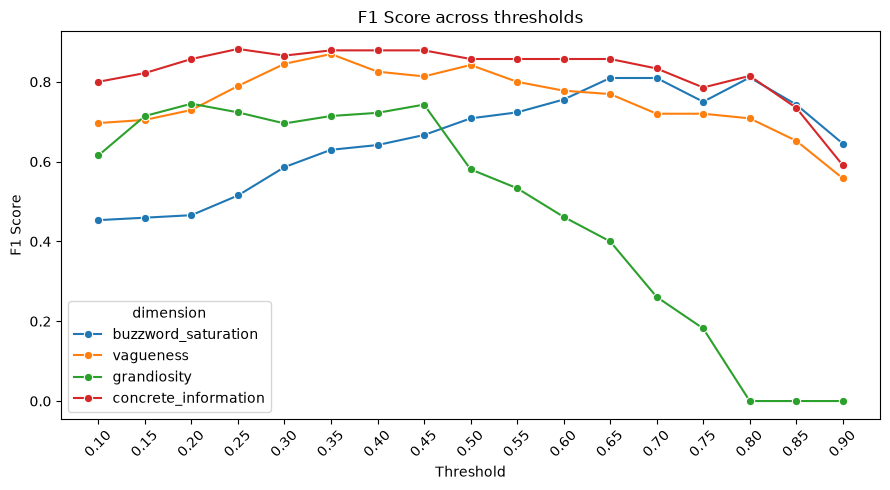

In [224]:
thresholds = np.arange(10, 91, 5) / 100
threshold_rows = []

for dimension, samples in prepared_by_dimension.items():
    for threshold in thresholds:
        binary_predictions = (samples["prediction"] >= threshold).astype(int)
        threshold_rows.append({
            "dimension": dimension,
            "threshold": threshold,
            "f1": f1_score(samples["label"], binary_predictions, zero_division=0),
            "precision": precision_score(samples["label"], binary_predictions, zero_division=0),
            "recall": recall_score(samples["label"], binary_predictions, zero_division=0),
        })

threshold_results = pd.DataFrame(threshold_rows)
best_f1_summary = (
    threshold_results.loc[
        threshold_results.groupby("dimension", sort=False)["f1"].idxmax(),
        ["dimension", "threshold", "f1", "precision", "recall"],
    ]
    .rename(columns={"threshold": "best_threshold"})
    .reset_index(drop=True)
)
display(best_f1_summary)

plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_results, x="threshold", y="f1", hue="dimension", marker="o")
plt.xticks(thresholds, rotation=45)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score across thresholds")
plt.tight_layout()
plt.show()

### Score Distributions

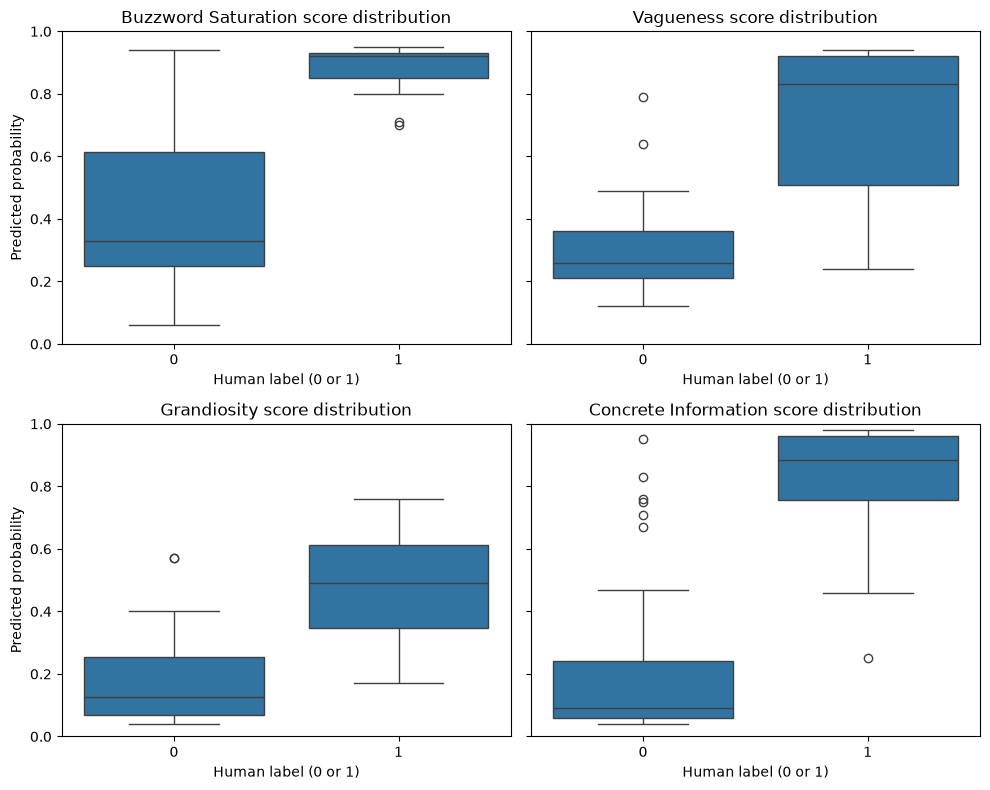

In [225]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

for (dimension, samples), ax in zip(prepared_by_dimension.items(), axes.flat):
    plot_data = samples.loc[samples["label"].isin([0, 1])].copy()
    plot_data["human_label"] = plot_data["label"].astype(str)

    sns.boxplot(data=plot_data, x="human_label", y="prediction", order=["0", "1"], ax=ax)
    ax.set_title(f"{dimension.replace('_', ' ').title()} score distribution")
    ax.set_xlabel("Human label (0 or 1)")
    ax.set_ylabel("Predicted probability")
    ax.set_ylim(0, 1)

fig.tight_layout()
plt.show()

### False Positive and False Negative Analysis

`error_confidence` is the probability assigned to the incorrect predicted class: `p` for false positives and `1 - p` for false negatives.

In [226]:
exploratory_thresholds = (
    threshold_results.loc[
        threshold_results.groupby("dimension", sort=False)["f1"].idxmax()
    ]
    .set_index("dimension")["threshold"]
)
error_columns = [
    "id", "text", "dimension", "human_label", "predicted_probability",
    "predicted_label", "error_type", "error_confidence",
]
error_frames = []

for dimension, prediction_col in dimension_columns.items():
    samples = evaluation_df.loc[
        evaluation_df[dimension] != "?", ["id", "text", dimension, prediction_col]
    ].copy()
    samples[dimension] = samples[dimension].astype(int)
    samples["predicted_label"] = (
        samples[prediction_col] >= exploratory_thresholds[dimension]
    ).astype(int)
    samples = samples.loc[samples[dimension] != samples["predicted_label"]].copy()
    samples["dimension"] = dimension
    samples["error_type"] = np.where(
        samples[dimension] == 0, "false_positive", "false_negative"
    )
    samples["error_confidence"] = np.where(
        samples["predicted_label"] == 1,
        samples[prediction_col],
        1 - samples[prediction_col],
    )
    samples = samples.rename(columns={
        dimension: "human_label", prediction_col: "predicted_probability"
    })
    error_frames.append(samples[error_columns])

error_analysis_df = (
    pd.concat(error_frames, ignore_index=True)
    .sort_values("error_confidence", ascending=False)
    .reset_index(drop=True)
)

for dimension in dimension_columns:
    for error_type in ("false_positive", "false_negative"):
        print(f"{dimension}: {error_type.replace('_', ' ')}")
        display(error_analysis_df.loc[
            (error_analysis_df["dimension"] == dimension)
            & (error_analysis_df["error_type"] == error_type)
        ].head(5))

buzzword_saturation: false positive


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
1,CBS023,"The financial landscape continues to evolve, a...",buzzword_saturation,0,0.94,1,false_positive,0.94
2,CBS050,Great leadership starts with people. We are cr...,buzzword_saturation,0,0.90,1,false_positive,0.90
3,CBS103,We believe in a more connected financial futur...,buzzword_saturation,0,0.90,1,false_positive,0.90
4,CBS035,"Together, we can accelerate a more sustainable...",buzzword_saturation,0,0.90,1,false_positive,0.90
5,CBS009,"Across the supply chain, connection matters mo...",buzzword_saturation,0,0.89,1,false_positive,0.89


buzzword_saturation: false negative


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
32,CBS007,Digital transformation becomes real on the fac...,buzzword_saturation,1,0.70,0,false_negative,0.30
34,CBS150,"In #healthcare AI, the gaps are clear: A trust...",buzzword_saturation,1,0.71,0,false_negative,0.29


vagueness: false positive


...

,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
6,CBS150,"In #healthcare AI, the gaps are clear: A trust...",grandiosity,1,0.17,0,false_negative,0.83


concrete_information: false positive


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
0,CBS168,Claude Opus 4 is our most powerful model yet a...,concrete_information,0,0.95,1,false_positive,0.95
7,CBS111,The startup announced a strategic intelligence...,concrete_information,0,0.83,1,false_positive,0.83
10,CBS074,A business plan should update when the busines...,concrete_information,0,0.76,1,false_positive,0.76
11,CBS173,Agentforce digital labor platform includes new...,concrete_information,0,0.75,1,false_positive,0.75
12,CBS013,We are testing a faster way to review repeat l...,concrete_information,0,0.71,1,false_positive,0.71


concrete_information: false negative


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence


## Corporate Bullshit Score


The four Jev decision scores describe separate linguistic characteristics, but the final detector requires a single interpretable **Corporate Bullshit Score**.

This score is not treated as a calibrated probability of whether a text is objectively "bullshit". Instead, it is a deterministic index derived from the four probabilistic decision signals.

Let:

- \(B\) = Buzzword Saturation
- \(V\) = Vagueness
- \(G\) = Grandiosity
- \(C\) = Concrete Information

All values lie between 0 and 1.

For the initial experiments, the positive bullshit signals are combined using heuristic weights:

$$
H = 0.30B + 0.40V + 0.30G
$$

The weights are intentionally not fitted to the golden dataset in order to reduce overfitting.

Concrete Information acts as a counter-signal.

### Approach A — Weighted Linear Score

The simplest approach subtracts Concrete Information directly from the weighted bullshit signals:

$$
S_A = \operatorname{clip}(H - \lambda C, 0, 1)
$$

with:

$$
\lambda = 0.45
$$

This approach is maximally transparent: buzzwords, vagueness, and grandiosity increase the score, while concrete information directly reduces it.


### Approach B — Evidence Discount

Instead of subtracting Concrete Information directly, it can be used as a proportional discount on the positive bullshit signal:

$$
S_B = H(1 - \lambda C)
$$

with:

$$
\lambda = 0.45
$$

This means concrete information reduces an existing bullshit signal rather than independently subtracting from the final score.

A text with very little hype therefore cannot receive a negative score, while a highly promotional but informative text retains some of its original signal.

In [227]:
BUZZWORD_WEIGHT = 0.30
VAGUENESS_WEIGHT = 0.40
GRANDIOSITY_WEIGHT = 0.30

CONCRETE_LAMBDA = 0.45

In [228]:
def _weighted_positive_signal(result: DecisionResult) -> float:
    return (
        BUZZWORD_WEIGHT * result.buzzword_saturation
        + VAGUENESS_WEIGHT * result.vagueness
        + GRANDIOSITY_WEIGHT * result.grandiosity
    )


def bullshit_score_linear(result: DecisionResult) -> float:
    score = _weighted_positive_signal(result) - CONCRETE_LAMBDA * result.concrete_information
    return min(1.0, max(0.0, score))

In [229]:
def bullshit_score_evidence_discount(result: DecisionResult) -> float:
    score = _weighted_positive_signal(result) * (
        1 - CONCRETE_LAMBDA * result.concrete_information
    )
    return min(1.0, max(0.0, score))

In [230]:
examples = [
    DecisionResult(0.9, 0.8, 0.7, 0.1),
    DecisionResult(0.4, 0.5, 0.3, 0.6)
]

for example in examples:
    print(
        bullshit_score_linear(example),
        bullshit_score_evidence_discount(example),
    )

0.755 0.764
0.14 0.2993


### Holdout Sanity Check

The handpicked, previously unseen LinkedIn posts provide a qualitative comparison against the informal `human_score` labels. These labels are not treated as trained or calibrated ground-truth probabilities.

In [231]:
holdout_df = pd.read_csv("../data/raw/linkedin_handpicked_holdout_samples.csv")

samples = [
    {
        "text": row["text"],
        "human_score": int(row["score"]),
    }
    for _, row in holdout_df.iterrows()
]

In [232]:
comparison_rows = []

for sample in samples:
    decision = jev_provider.analyze(sample["text"])
    comparison_rows.append({
        "text": sample["text"],
        "human_score": sample["human_score"],
        "buzzword_score": decision.buzzword_saturation,
        "vagueness_score": decision.vagueness,
        "grandiosity_score": decision.grandiosity,
        "concrete_information_score": decision.concrete_information,
        "score_a_linear": bullshit_score_linear(decision),
        "score_b_evidence_discount": bullshit_score_evidence_discount(decision)
    })

In [233]:
comparison_columns = [
    "text",
    "human_score",
    "buzzword_score",
    "vagueness_score",
    "grandiosity_score",
    "concrete_information_score",
    "score_a_linear",
    "score_b_evidence_discount",
]

comparison_df = pd.DataFrame(comparison_rows, columns=comparison_columns)
display(comparison_df.round(3))

,text,human_score,buzzword_score,vagueness_score,grandiosity_score,concrete_information_score,score_a_linear,score_b_evidence_discount
0,Motorsports legend H. M. invests in a Graz-bas...,0,0.79,0.53,0.38,0.61,0.288,0.408
1,Some lost sales never show up as abandoned car...,0,0.36,0.43,0.16,0.10,0.283,0.313
2,Al-powered search is no longer a future threat...,1,0.95,0.59,0.83,0.56,0.518,0.576
3,I’m happy to share that today is the day I am ...,0,0.81,0.92,0.32,0.08,0.671,0.682
4,"Technical equipment, machinery, and facilities...",0,0.32,0.84,0.18,0.07,0.454,0.471
5,We’re revealing the new Copilot today. A lot o...,0,0.32,0.85,0.16,0.12,0.430,0.458
6,Agentic Voice AI is much more than automated c...,1,0.88,0.72,0.79,0.12,0.735,0.746
7,At the enterprise level: fonio.ai has entered ...,0,0.67,0.32,0.15,0.79,0.018,0.241
8,Mobility looks different depending on where pe...,0,0.25,0.82,0.10,0.09,0.393,0.415
9,Your AI agent just wrote code. Now where do yo...,0,0.89,0.26,0.34,0.68,0.167,0.328


### Final Score: Evidence Discount

The final Corporate Bullshit Score uses the **Evidence Discount** approach:

$$
H = 0.30B + 0.40V + 0.30G
$$

$$
S = H(1 - 0.45C)
$$

where:

- \(B\) = Buzzword Saturation
- \(V\) = Vagueness
- \(G\) = Grandiosity
- \(C\) = Concrete Information

The Evidence Discount approach was selected because it provides a simple and interpretable balance between positive bullshit signals and concrete substance.

Unlike direct subtraction, concrete information does not independently push the score toward zero. Instead, it proportionally reduces the strength of the existing bullshit signal. This allows informative marketing or technical communication to retain some hype-related signal without being classified as strongly as vague, unsupported communication.

The weights are heuristic rather than fitted to the evaluation dataset. This keeps the scoring logic transparent and reduces the risk of overfitting the small golden set.

The resulting value is a **Corporate Bullshit Score**, not a calibrated probability that a text is objectively bullshit.

#### Score Levels

| Score | Level | Explanation |
|---|---|---|
| **0–29** | **Looks Fine** | Mostly straightforward communication with enough concrete substance to keep the corporate fog under control. |
| **30–49** | **Hmm... Suspicious** | Some corporate fog is creeping in, but there is still enough substance to give it the benefit of the doubt. |
| **50–69** | **Getting Bullshitty** | Hype, vagueness, or inflated claims are starting to outweigh the useful information. |
| **70–100** | **Yep, That's Bullshit** | Corporate rhetoric is doing considerably more work than the actual substance. |

In [234]:
@dataclass
class BullshitVerdict:
    bullshit_score: int
    level: str
    color: str
    explanation: str


def interpret_bullshit_score(raw_score: float) -> BullshitVerdict:
    if not 0.0 <= raw_score <= 1.0:
        raise ValueError("raw_score must be between 0.0 and 1.0.")

    bullshit_score = round(raw_score * 100)

    if bullshit_score <= 29:
        level = "Looks Fine"
        color = "green"
        explanation = (
            "Mostly straightforward communication with enough concrete substance to keep "
            "the corporate fog under control."
        )
    elif bullshit_score <= 49:
        level = "Hmm... Suspicious"
        color = "yellow"
        explanation = (
            "Some corporate fog is creeping in, but there is still enough substance to give "
            "it the benefit of the doubt."
        )
    elif bullshit_score <= 69:
        level = "Getting Bullshitty"
        color = "orange"
        explanation = (
            "Hype, vagueness, or inflated claims are starting to outweigh the useful "
            "information."
        )
    else:
        level = "Yep, That's Bullshit"
        color = "red"
        explanation = (
            "Corporate rhetoric is doing considerably more work than the actual substance."
        )

    return BullshitVerdict(bullshit_score, level, color, explanation)

In [235]:
def analyze_corporate_text(
    text: str, provider: DecisionProvider
) -> BullshitVerdict:
    decision = provider.analyze(text)
    raw_score = bullshit_score_evidence_discount(decision)
    return interpret_bullshit_score(raw_score)


def print_bullshit_verdict(verdict: BullshitVerdict):
    ansi_colors = {
        "green": "\033[32m",
        "yellow": "\033[33m",
        "orange": "\033[93m",
        "red": "\033[31m",
    }
    reset = "\033[0m"
    color = ansi_colors[verdict.color]

    print("Corporate Bullshit Detector™")
    print()
    print(f"Bullshit Score: {verdict.bullshit_score}/100")
    print(f"{color}{verdict.level}{reset}")
    print()
    print(verdict.explanation)

## End-to-End Examples

The following examples demonstrate the complete Corporate Bullshit Detector™ pipeline on four illustrative texts. They are not part of the evaluation dataset and are used only to show how the final system behaves from raw text input to the user-facing score.

In [236]:
end_to_end_examples = [
    {
        "example": "Technical Update",
        "text": (
            "We deployed a new checkout service this week. Median API latency decreased "
            "from 420 ms to 260 ms, and the error rate dropped from 1.8% to 0.7%. The "
            "rollout is currently handling 25% of production traffic before the final migration."
        ),
    },
    {
        "example": "Business Announcement",
        "text": (
            "We have opened a second office in Graz and added six new customer-support roles. "
            "The new location will support customers in Austria and southern Germany and is "
            "expected to be fully operational by November."
        ),
    },
    {
        "example": "Corporate Transformation",
        "text": (
            "We are redefining the future of enterprise innovation through a next-generation "
            "AI-powered ecosystem designed to unlock unprecedented synergies, accelerate "
            "transformation, and empower organizations to thrive in an increasingly dynamic world."
        ),
    },
    {
        "example": "Founder Vision",
        "text": (
            "Today marks the beginning of a new era. We are building a category-defining agentic "
            "AI platform that will fundamentally transform how companies operate, collaborate, "
            "and create value at scale. This is more than a product launch — it is a paradigm "
            "shift for the future of work."
        ),
    },
]

In [237]:
end_to_end_rows = []

for example in end_to_end_examples:
    decision = jev_provider.analyze(example["text"])
    raw_score = bullshit_score_evidence_discount(decision)
    verdict = interpret_bullshit_score(raw_score)

    end_to_end_rows.append({
        "example": example["example"],
        "text": example["text"],
        "buzzword_saturation": decision.buzzword_saturation,
        "vagueness": decision.vagueness,
        "grandiosity": decision.grandiosity,
        "concrete_information": decision.concrete_information,
        "bullshit_score": verdict.bullshit_score,
        "level": verdict.level,
        "explanation": verdict.explanation,
    })

end_to_end_df = pd.DataFrame(end_to_end_rows, columns=[
    "example",
    "text",
    "buzzword_saturation",
    "vagueness",
    "grandiosity",
    "concrete_information",
    "bullshit_score",
    "level",
    "explanation",
])

decision_columns = [
    "buzzword_saturation",
    "vagueness",
    "grandiosity",
    "concrete_information",
]
display(end_to_end_df.round({column: 3 for column in decision_columns}))

,example,text,buzzword_saturation,vagueness,grandiosity,concrete_information,bullshit_score,level,explanation
0,Technical Update,We deployed a new checkout service this week. ...,0.23,0.12,0.07,0.98,8,Looks Fine,Mostly straightforward communication with enou...
1,Business Announcement,We have opened a second office in Graz and add...,0.16,0.20,0.07,0.95,9,Looks Fine,Mostly straightforward communication with enou...
2,Corporate Transformation,We are redefining the future of enterprise inn...,0.98,0.95,0.93,0.04,94,"Yep, That's Bullshit",Corporate rhetoric is doing considerably more ...
3,Founder Vision,Today marks the beginning of a new era. We are...,0.97,0.91,0.92,0.08,90,"Yep, That's Bullshit",Corporate rhetoric is doing considerably more ...


## Conclusion

The Corporate Bullshit Detector demonstrates a simple and transparent approach to evaluating corporate and professional social-media communication without reducing the task to a single opaque classification.

By separating the analysis into **buzzword saturation, vagueness, grandiosity, and concrete information**, the system captures different aspects of corporate rhetoric independently. On the manually labeled golden set, Jev showed strong separation across all four dimensions, while qualitative tests on previously unseen LinkedIn posts also exposed realistic edge cases and ambiguities.

The final **Evidence Discount** score combines the three positive bullshit signals while allowing concrete information to reduce, rather than completely erase, them. The resulting **0–100 Corporate Bullshit Score is an experimental index, not a calibrated probability or an objective measure of truthfulness**.

The project should therefore be understood as a practical and slightly ridiculous experiment in probabilistic language analysis — useful for detecting corporate fog, but not as the final authority on whether someone is, in fact, full of bullshit.